
#### Import Necessary Modules

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mungle_helper import Mungler as mh
import io
import os

In [13]:
%matplotlib inline

In [14]:
used_car_sale_prices = pd.read_csv('used_car_sale_prices.csv', index_col=False)


#### Descriptive Statistics


In [15]:
used_car_sale_prices.head()

,Id,Model,Price,Age_08_04,KM,Fuel_Type,HP,Color,Automatic,CC,...,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Mfg_Date
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,46986,Diesel,90,Blue (Metallic),No,2000,...,Yes,No,No,No,Yes,No,No,No,No,10/1/02
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,72937,Diesel,90,Silver (Metallic),No,2000,...,Yes,No,No,No,Yes,No,No,No,No,10/1/02
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,41711,Diesel,90,Blue (Metallic),No,2000,...,Yes,No,No,No,Yes,No,No,No,No,9/1/02
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,48000,Diesel,90,Black,No,2000,...,Yes,No,No,No,Yes,No,No,No,No,7/1/02
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,38500,Diesel,90,Black,No,2000,...,Yes,No,Yes,No,Yes,No,No,No,No,3/1/02


In [16]:
used_car_sale_prices.tail()

,Id,Model,Price,Age_08_04,KM,Fuel_Type,HP,Color,Automatic,CC,...,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Mfg_Date
1431,1438,TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors,7500,69,20544,Petrol,86,Blue (Metallic),No,1300,...,Yes,No,Yes,Yes,Yes,No,No,No,No,12/1/98
1432,1439,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,10845,72,19000,Petrol,86,Grey,No,1300,...,Yes,No,No,Yes,Yes,No,No,No,No,9/1/98
1433,1440,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,8500,71,17016,Petrol,86,Blue,No,1300,...,Yes,No,No,No,Yes,No,No,No,No,10/1/98
1434,1441,TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...,7250,70,16916,Petrol,86,Grey (Metallic),No,1300,...,No,No,No,No,Yes,No,No,No,No,11/1/98
1435,1442,TOYOTA Corolla 1.6 LB LINEA TERRA 4/5-Doors,6950,76,1,Petrol,110,Green,No,1600,...,Yes,No,No,No,No,No,No,No,No,5/1/98


In [17]:
used_car_sale_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   KM                 1436 non-null   int64 
 5   Fuel_Type          1436 non-null   object
 6   HP                 1436 non-null   int64 
 7   Color              1436 non-null   object
 8   Automatic          1436 non-null   object
 9   CC                 1436 non-null   int64 
 10  Doors              1436 non-null   int64 
 11  Cylinders          1436 non-null   int64 
 12  Gears              1436 non-null   int64 
 13  Quarterly_Tax      1436 non-null   int64 
 14  Weight             1436 non-null   int64 
 15  Mfr_Guarantee      1436 non-null   object
 16  BOVAG_Guarantee    1436 non-null   object


In [18]:
used_car_sale_prices.describe()

,Id,Price,Age_08_04,KM,HP,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Guarantee_Period
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000
mean,721.555014,10681.468663,55.947075,68533.259749,101.502089,1576.85585,4.033426,3.770195,5.026462,86.838440,1072.45961,3.815460
std,416.476890,3621.377346,18.599988,37506.448872,14.981080,424.38677,0.952677,1.047367,0.188510,41.297734,52.64112,3.011025
min,1.000000,1625.000000,1.000000,1.000000,69.000000,1300.00000,2.000000,-1.000000,3.000000,0.000000,1000.00000,3.000000
25%,361.750000,8450.000000,44.000000,43000.000000,90.000000,1400.00000,3.000000,4.000000,5.000000,69.000000,1040.00000,3.000000
50%,721.500000,9900.000000,61.000000,63389.500000,110.000000,1600.00000,4.000000,4.000000,5.000000,85.000000,1070.00000,3.000000
75%,1081.250000,11935.000000,70.000000,87020.750000,110.000000,1600.00000,5.000000,4.000000,5.000000,85.000000,1085.00000,3.000000
max,1442.000000,32500.000000,80.000000,243000.000000,192.000000,16000.00000,5.000000,4.000000,6.000000,283.000000,1615.00000,36.000000


In [19]:
used_car_sale_prices.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
KM                   0
Fuel_Type            0
HP                   0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
Mfg_Date             0
dtype: int64

In [20]:
x_vars = used_car_sale_prices.columns.drop(['Id', 'Price'])
y_var = used_car_sale_prices['Price']

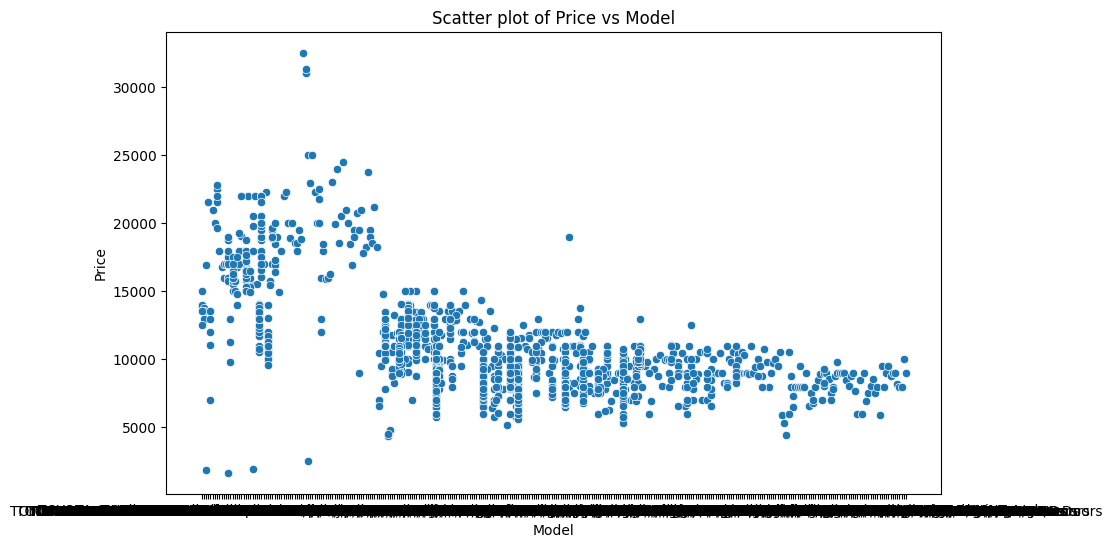

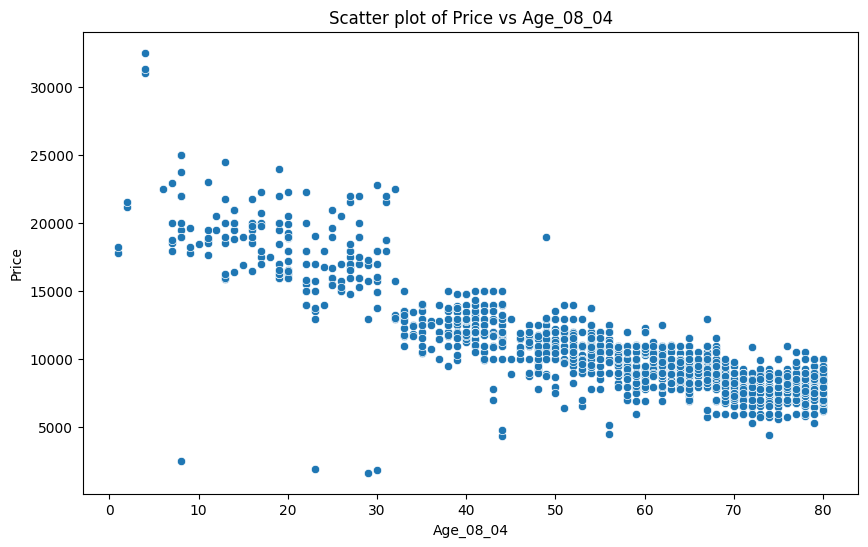

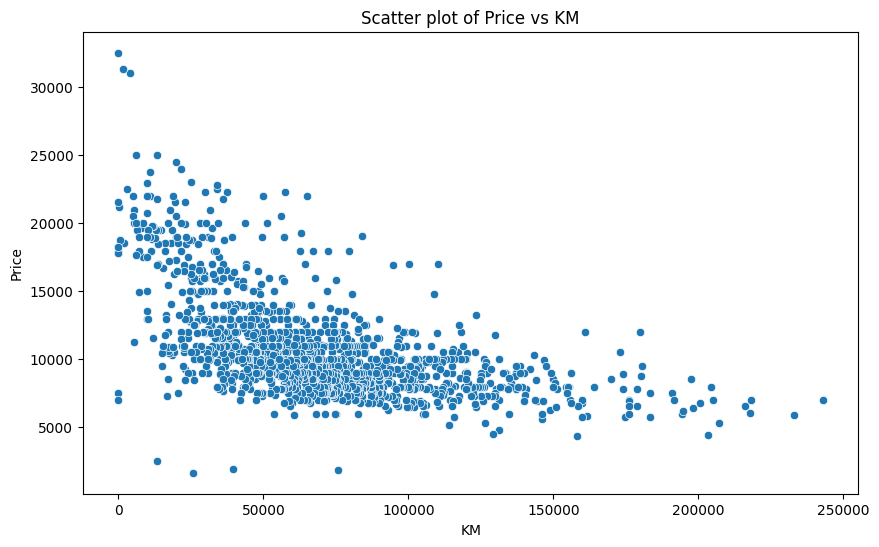

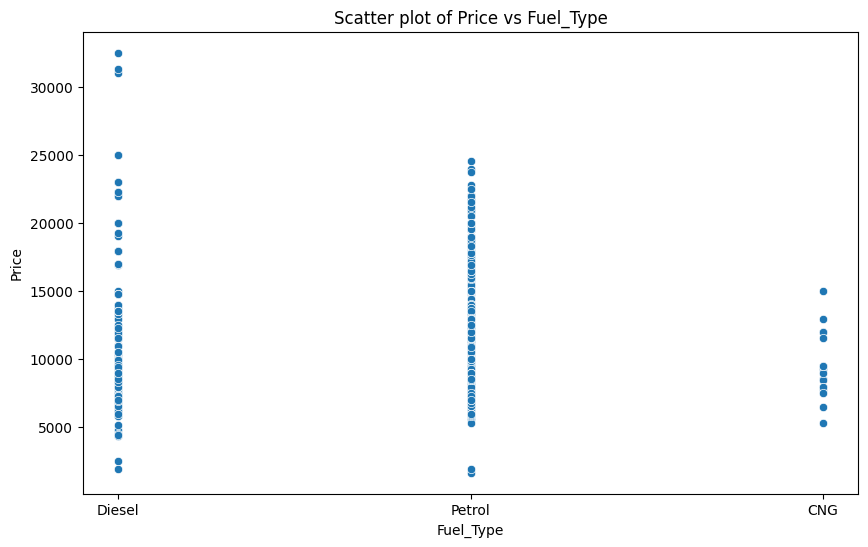

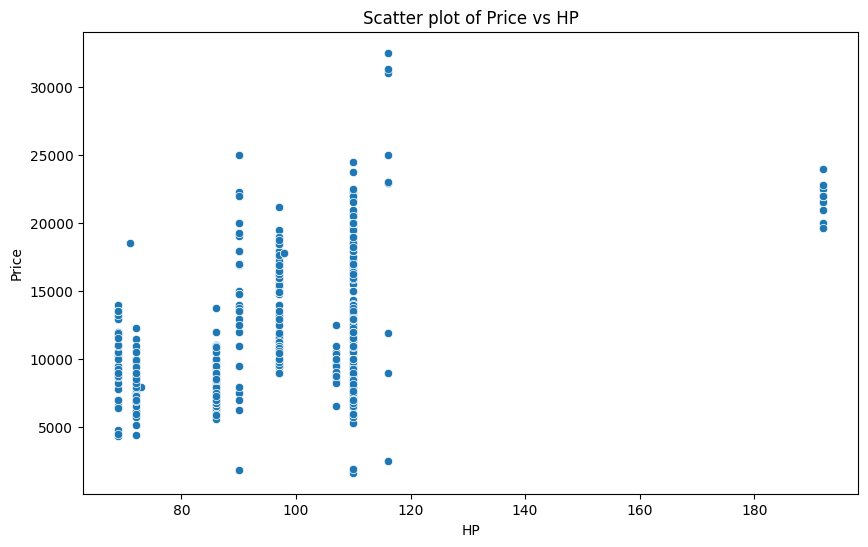

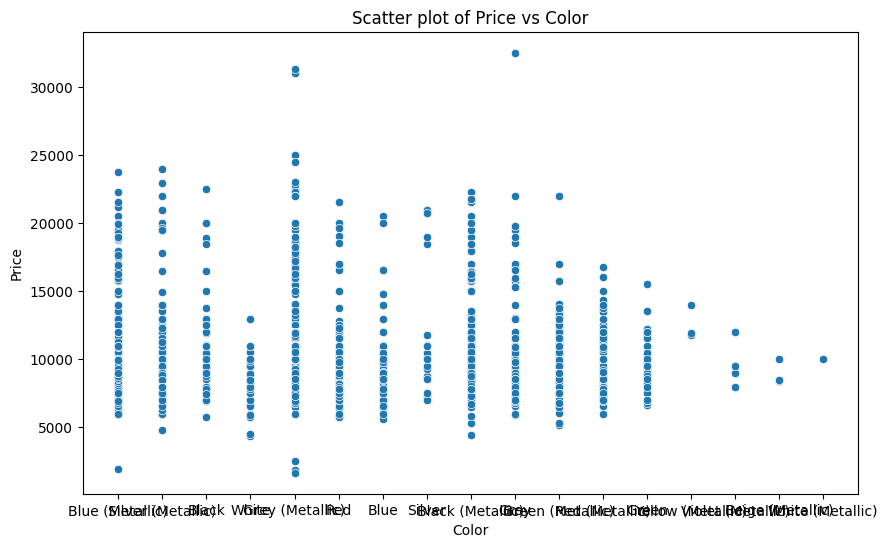

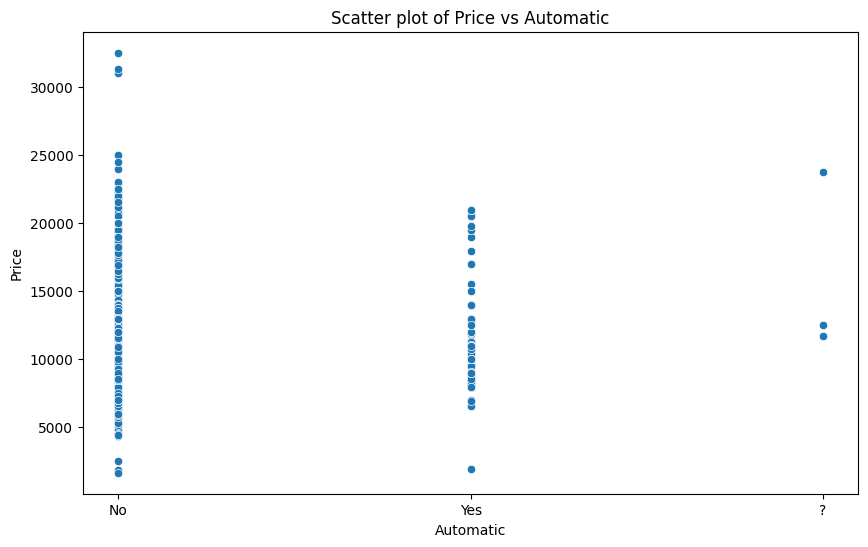

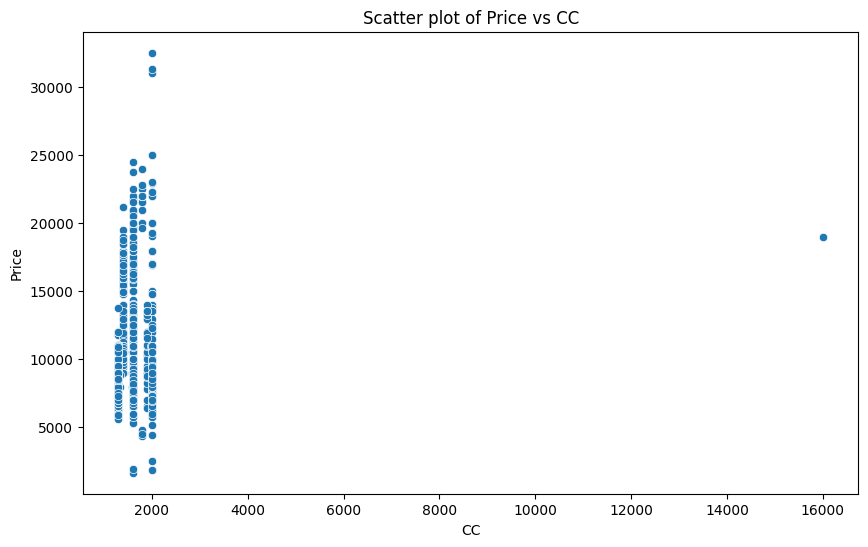

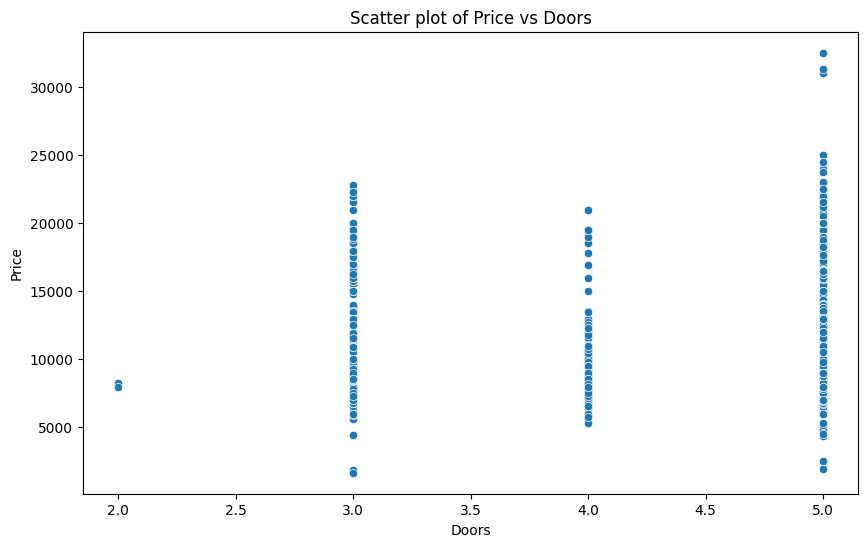

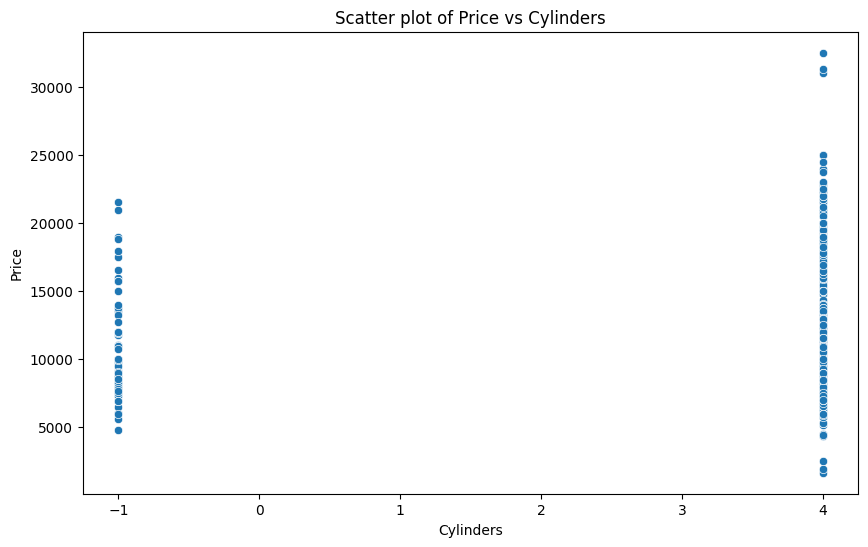

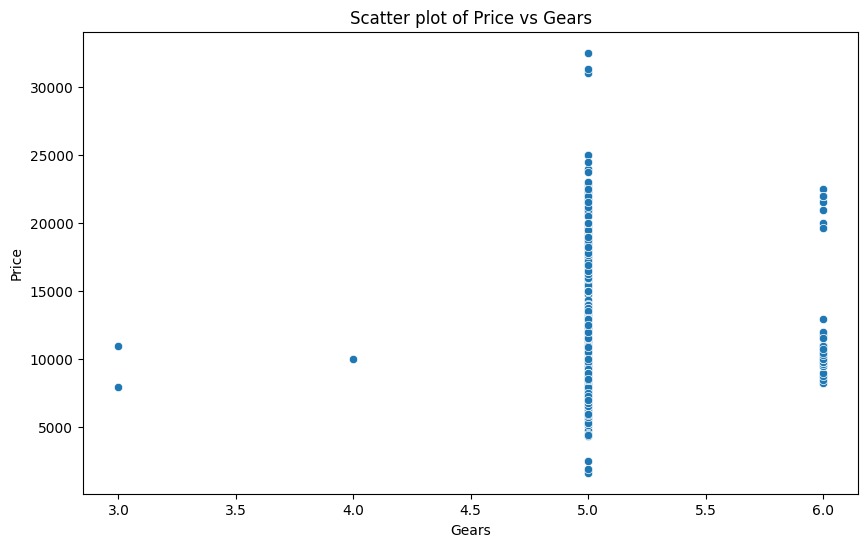

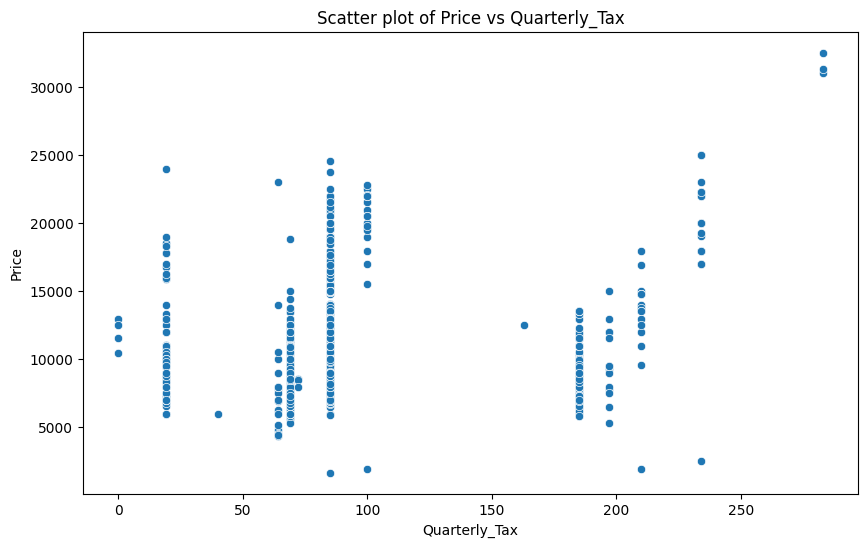

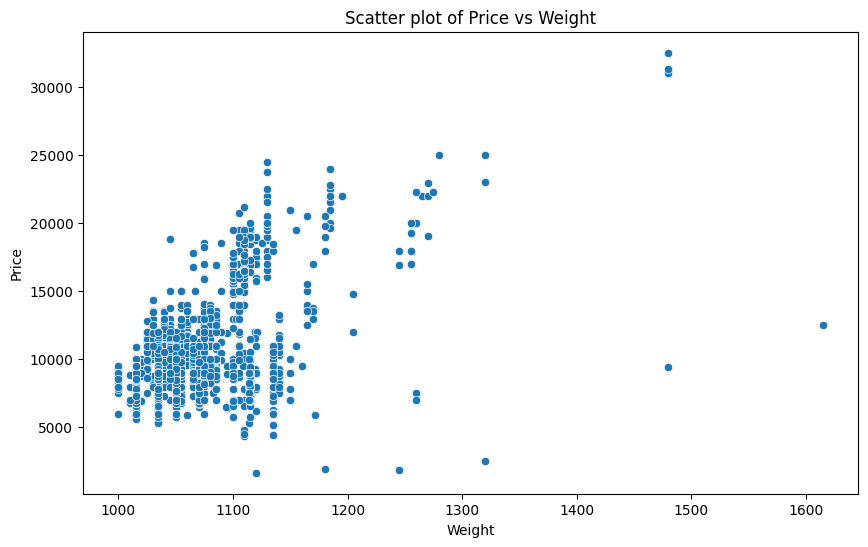

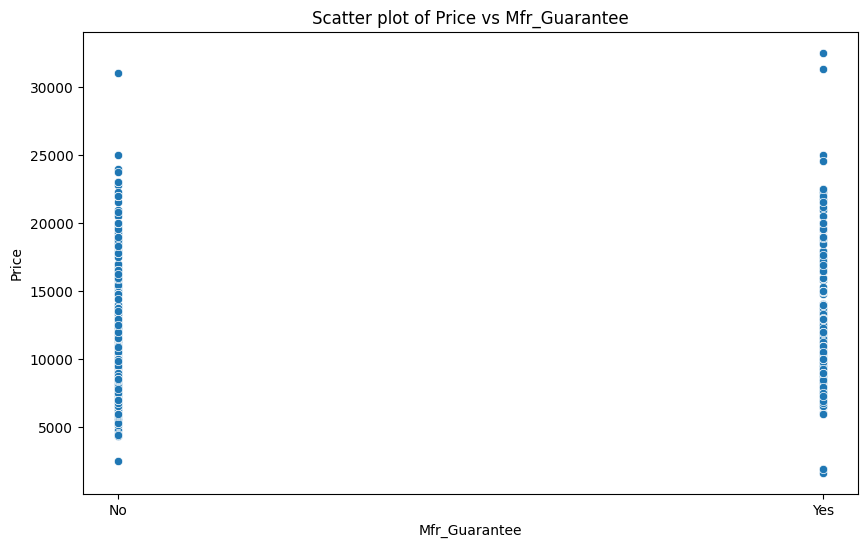

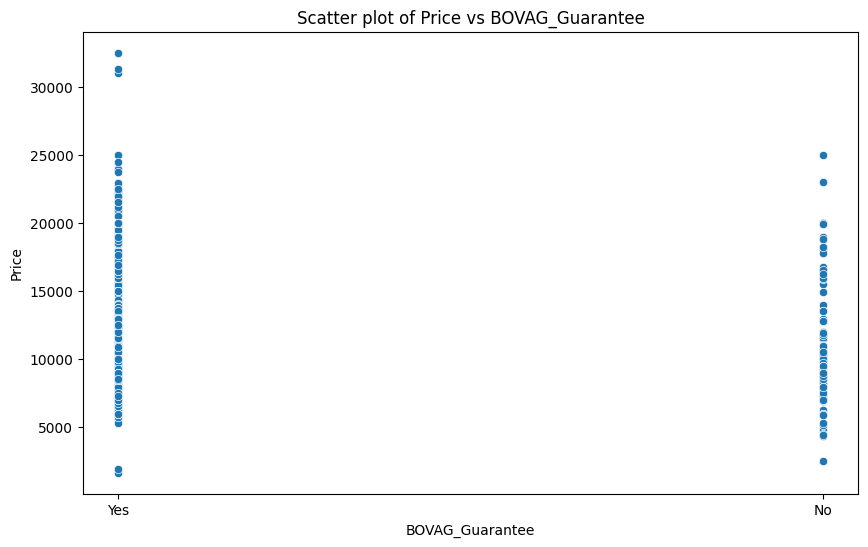

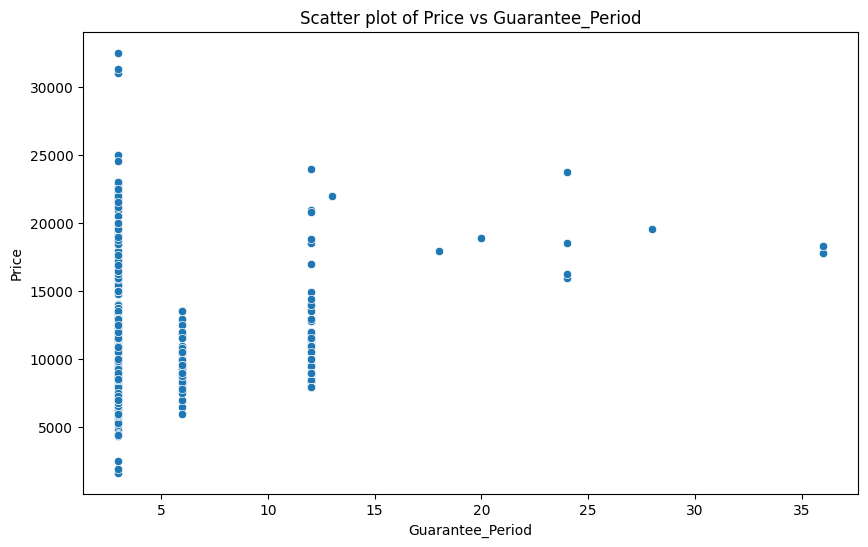

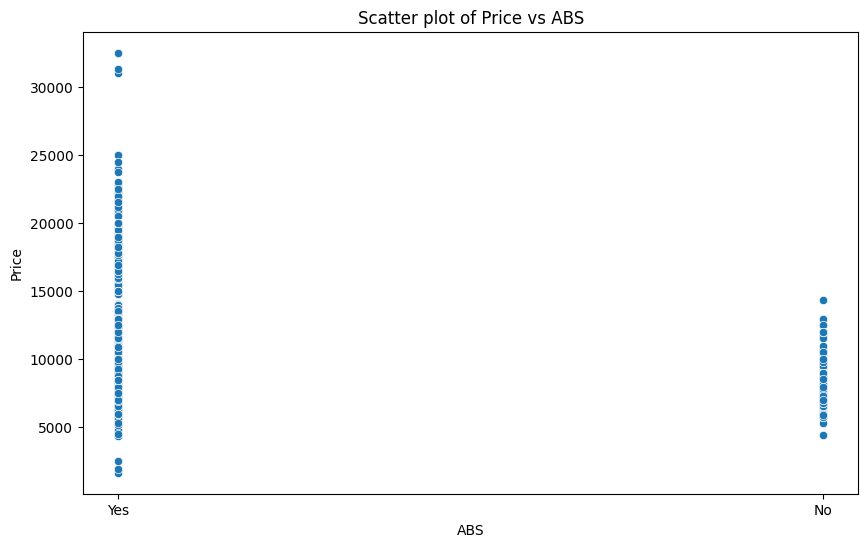

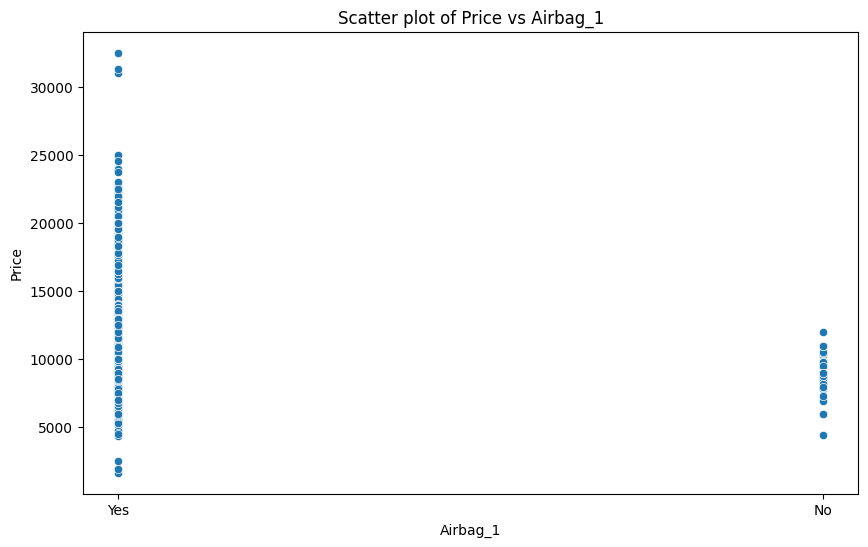

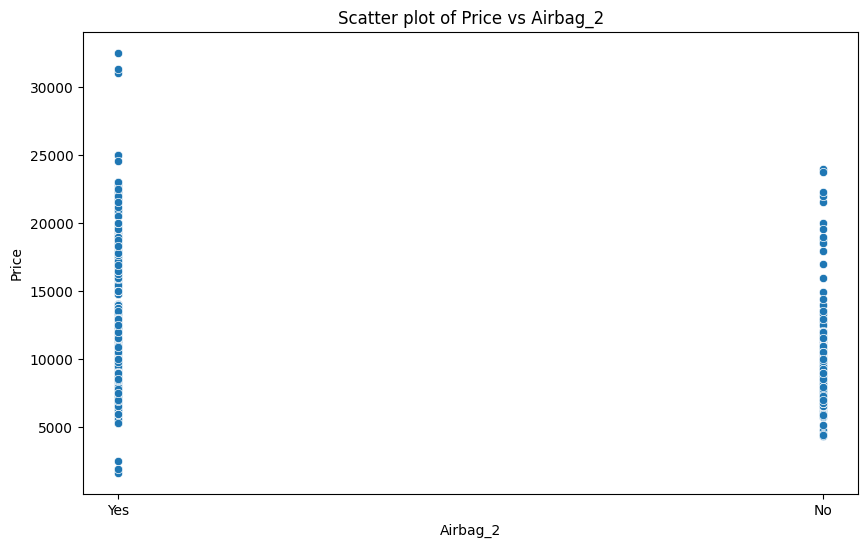

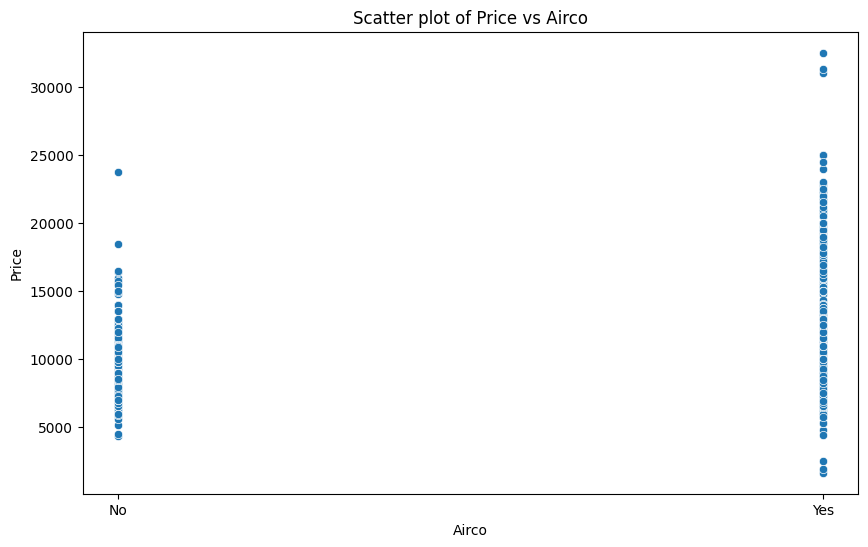

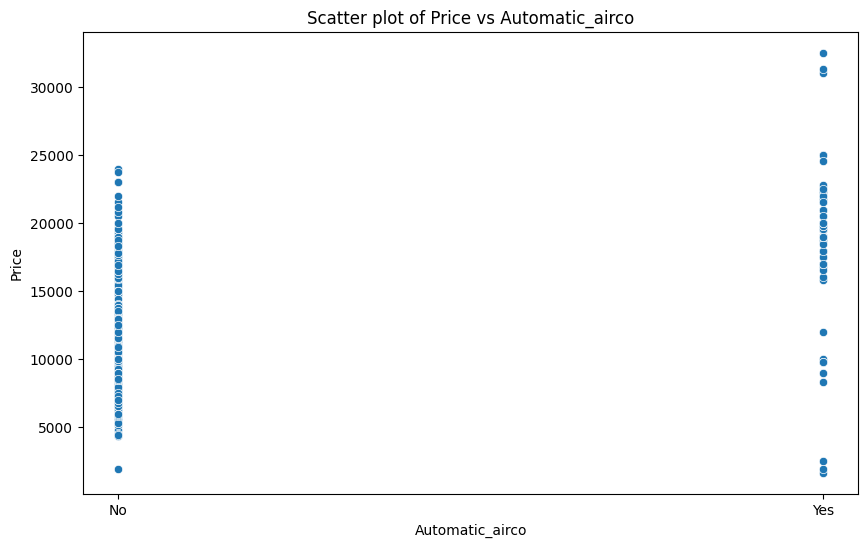

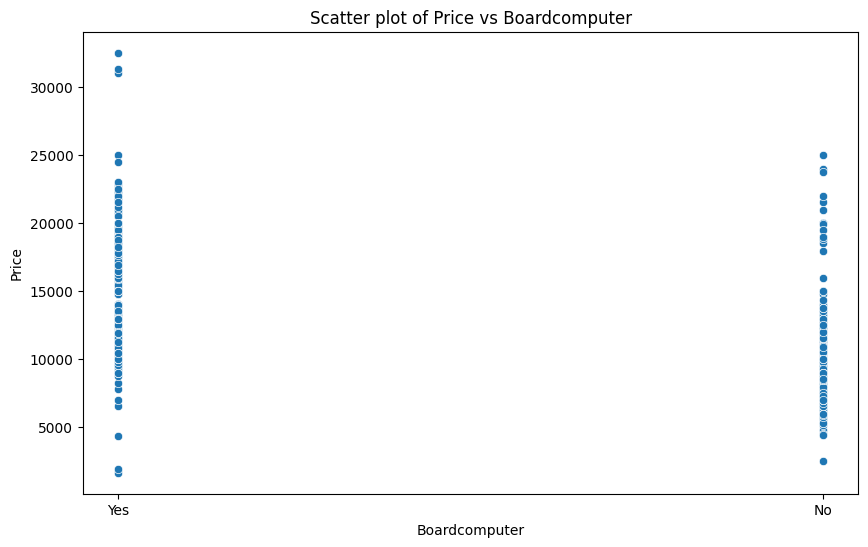

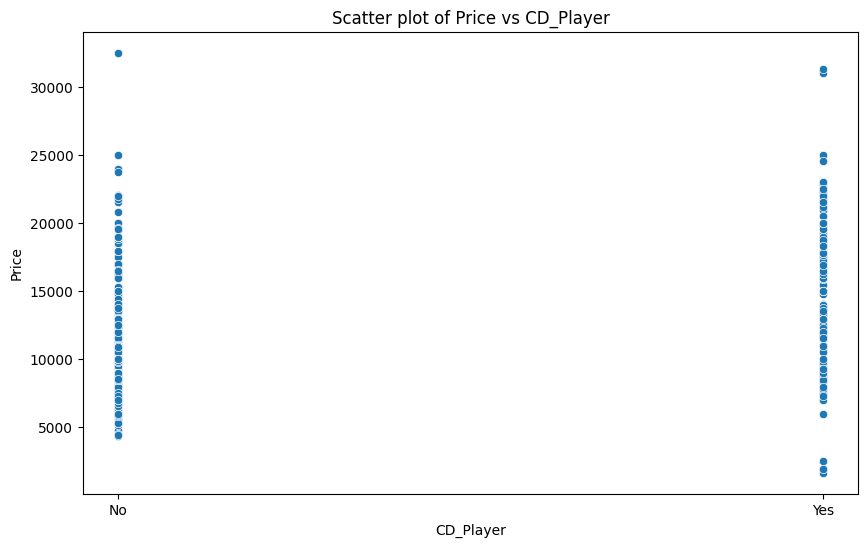

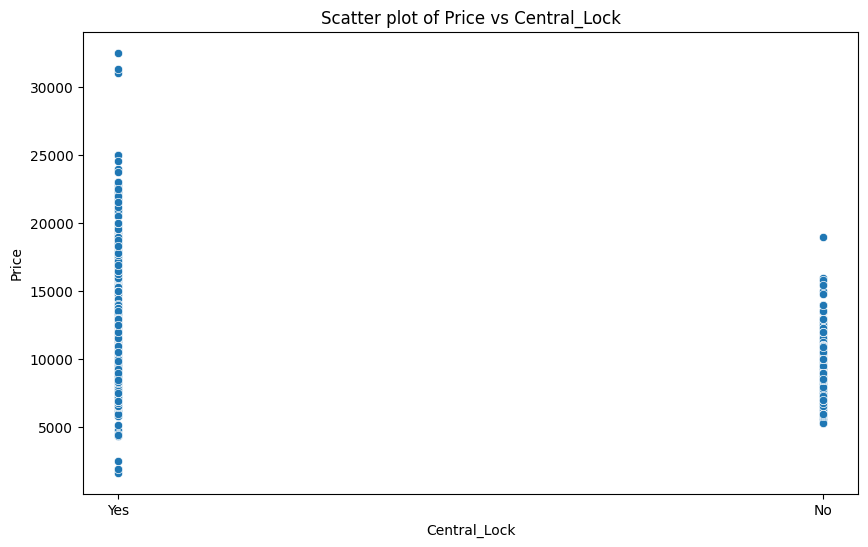

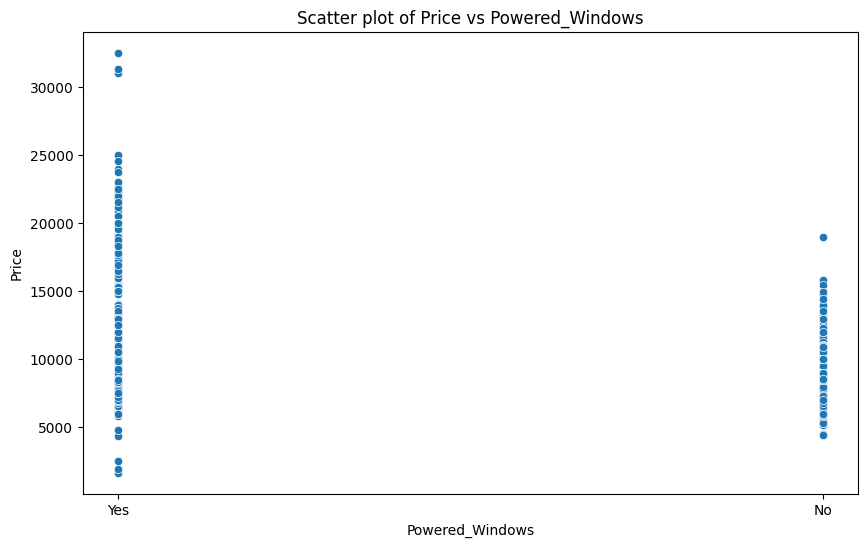

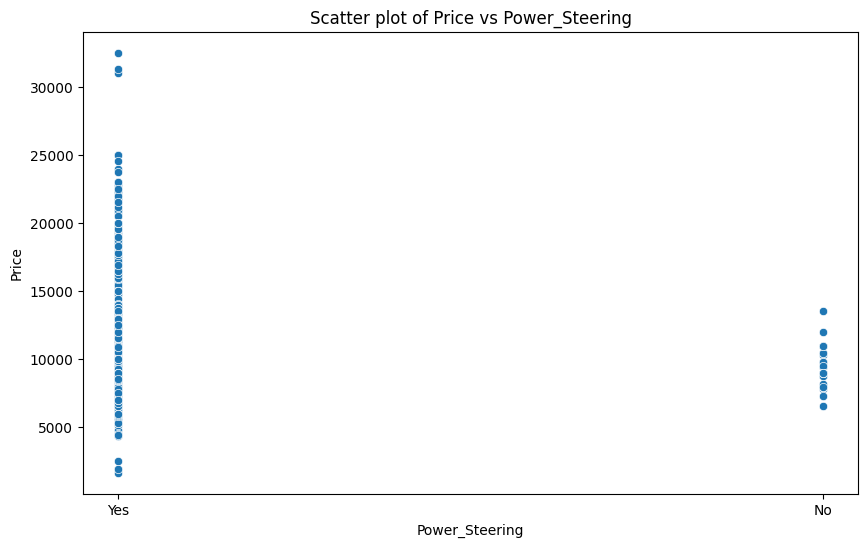

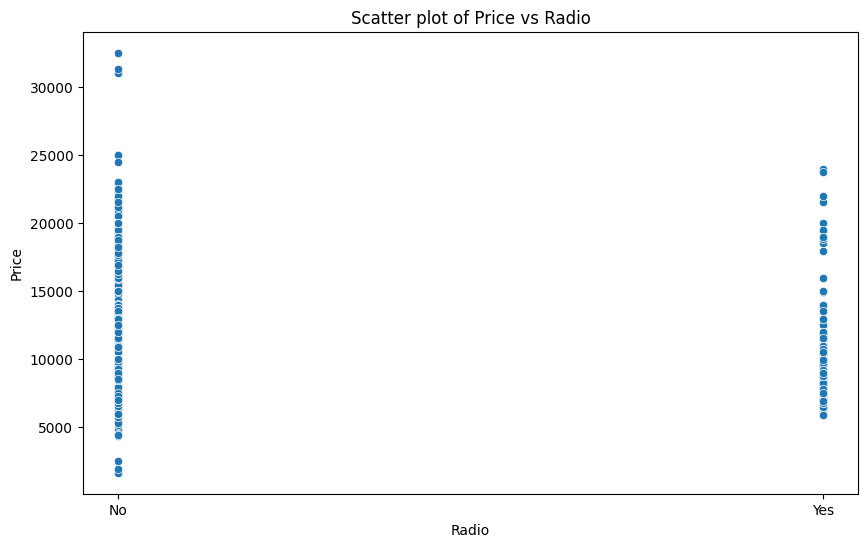

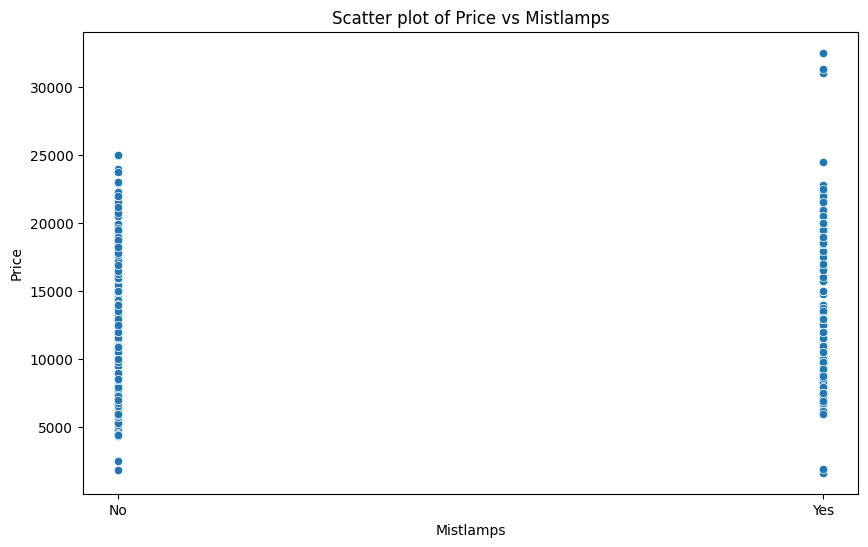

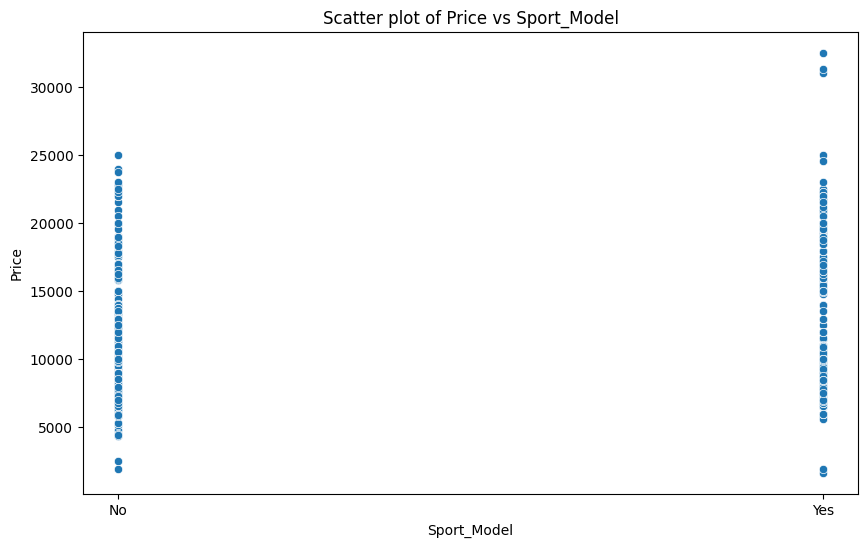

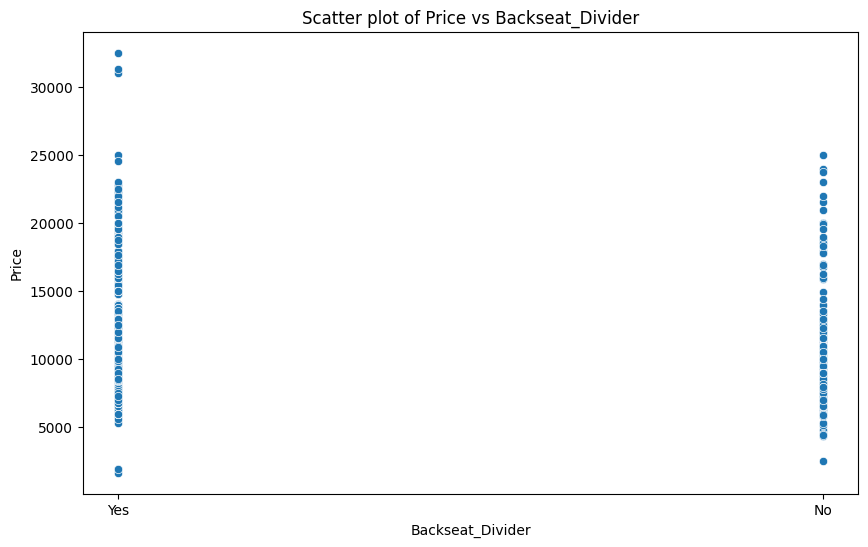

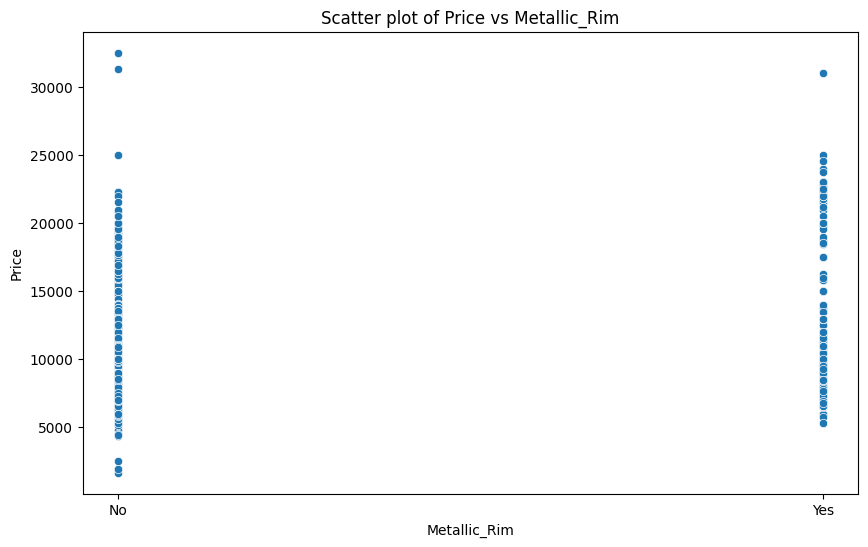

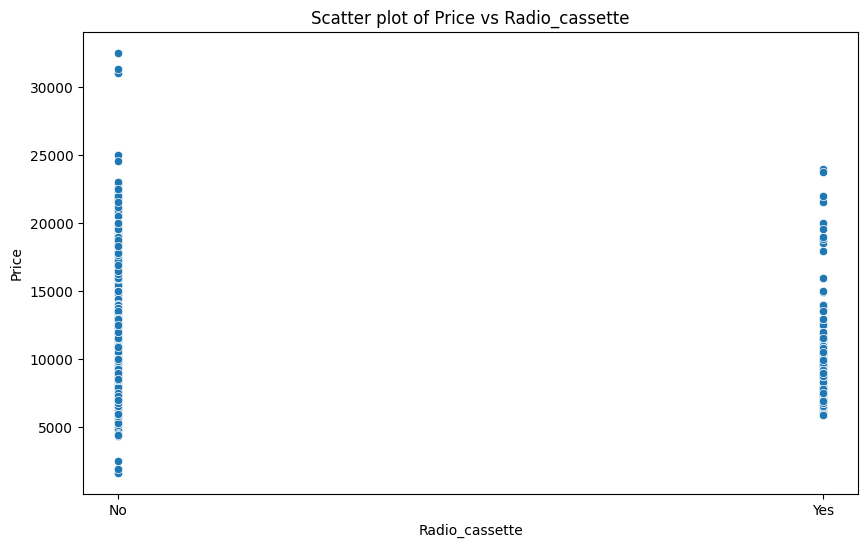

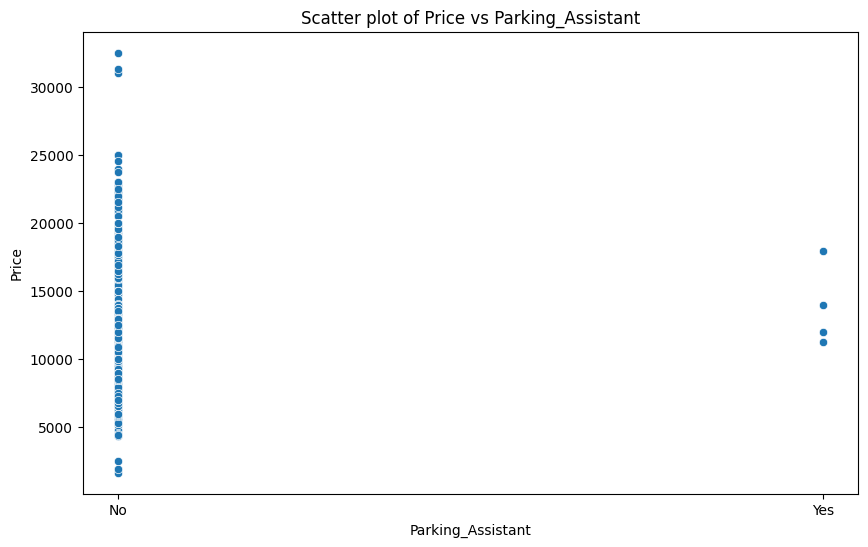

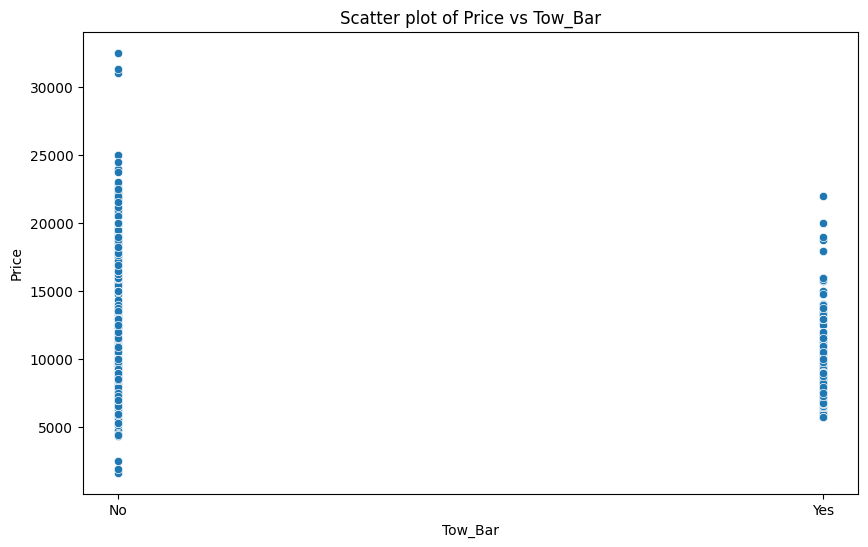

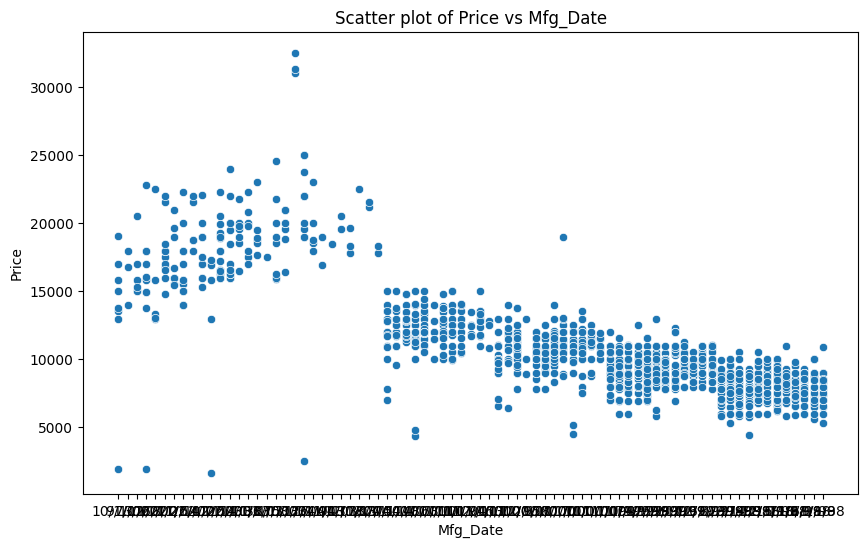

In [21]:
for col in x_vars:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=used_car_sale_prices, x=col, y='Price')
    plt.title(f'Scatter plot of Price vs {col}')
    plt.xlabel(col)
    plt.ylabel('Price')
    plt.show()

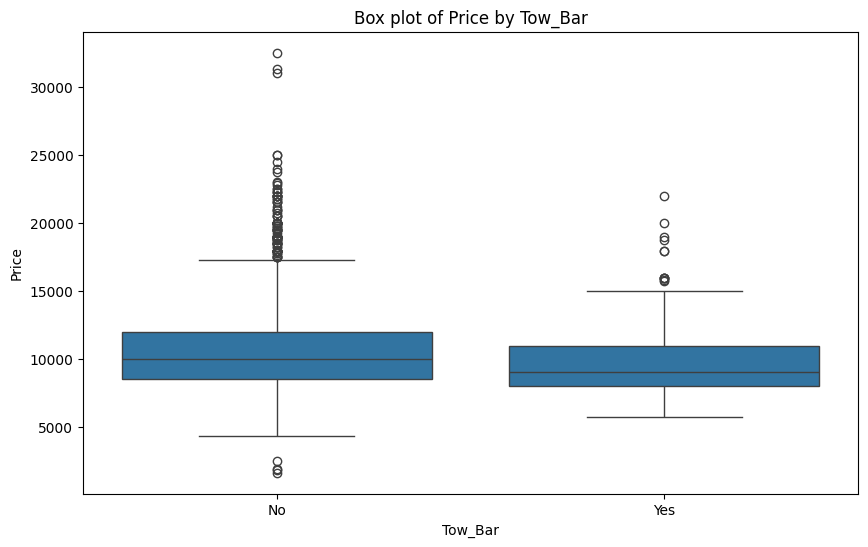

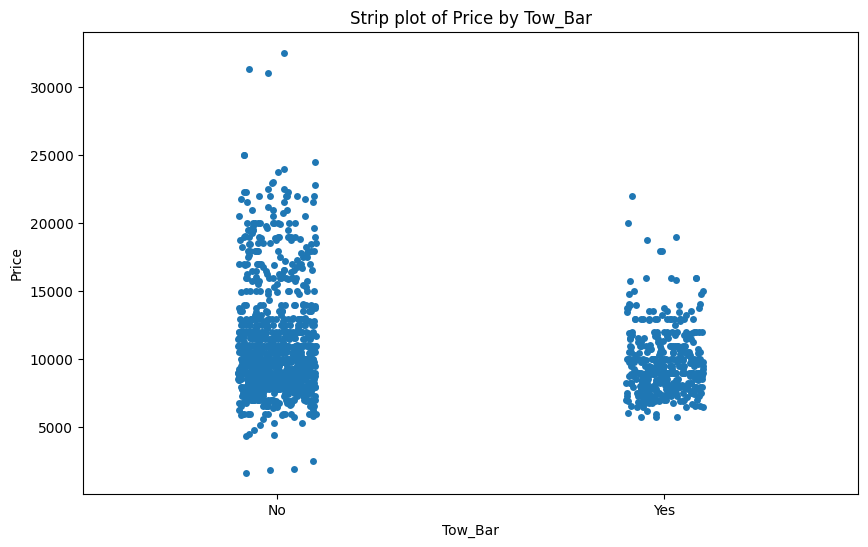

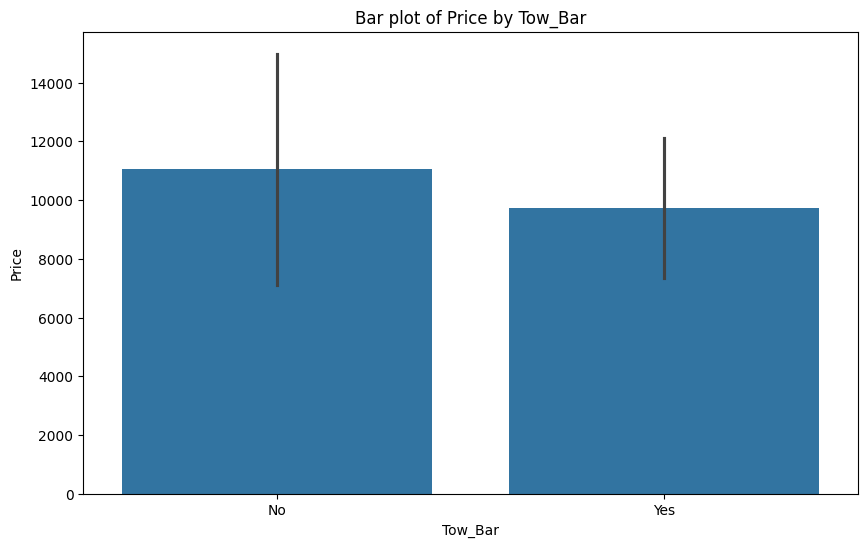

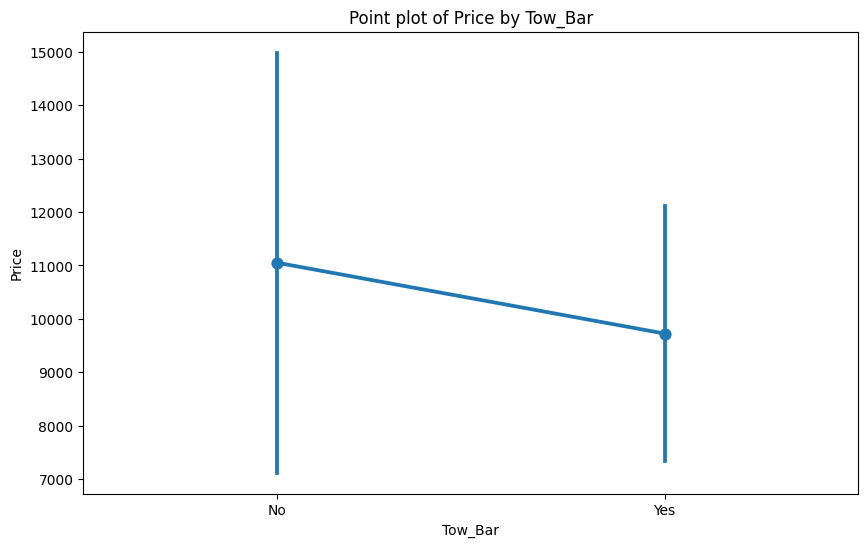

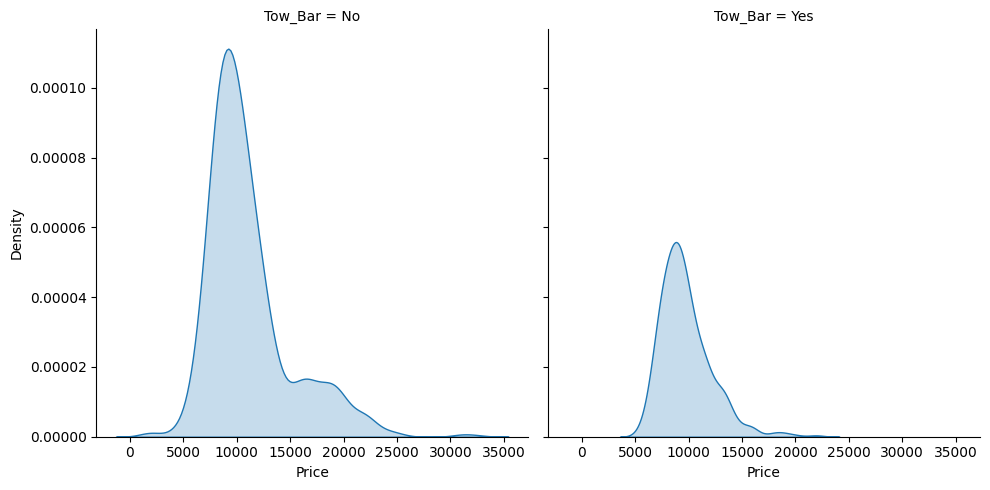

In [22]:
mh.categorical_visualizations(used_car_sale_prices, 'Tow_Bar', 'Price')